## Importing libraries and formatting plots

In [1]:
# Importing crap
# %load_ext autoreload
# %autoreload 2

import sys
sys.path.append('../../')

import numpy as np
import pandas as pd
import numexpr

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics as IRSC

import VBMicrolensing
import MulensModel as mm

import csv

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['figure.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 20
plt.rcParams['mathtext.fontset'] = 'cm'

## Reading in analysis output file

In [13]:
df_1 = pd.read_csv('./analysis_output.csv')
df_2 = pd.read_csv('./analysis_output_2.csv')

In [14]:
ss_str_1 = np.array(df_1['s'].to_list(), dtype=str)
ss_1 = np.array([numexpr.evaluate(str(s)) for s in df_1['s'].to_list()])
qs_1 = np.array(df_1['q'].to_list())
thresholds_1 = np.array(df_1.columns[4:], dtype=float)

ss_str_2 = np.array(df_2['s'].to_list(), dtype=str)
ss_2 = np.array([numexpr.evaluate(str(s)) for s in df_2['s'].to_list()])
qs_2 = np.array(df_2['q'].to_list())
thresholds_2 = np.array(df_2.columns[4:], dtype=float)

In [15]:
ss_str_unique_1 = np.unique(ss_str_1)
ss_unique_1 = np.unique(ss_1)
qs_unique_1 = np.unique(qs_1)

ss_str_unique_2 = np.unique(ss_str_2)
ss_unique_2 = np.unique(ss_2)
qs_unique_2 = np.unique(qs_2)

## Plotting cumulative distributions for q = 1e-4 and all s

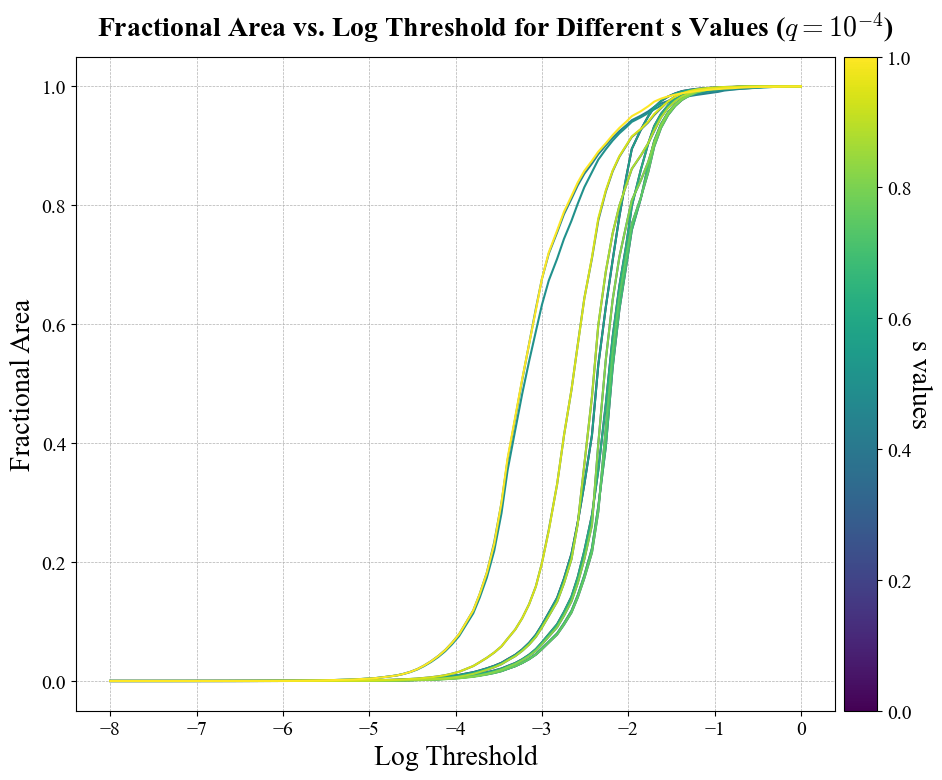

In [16]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Fractional Area vs. Log Threshold for Different s Values ($q=10^{-4}$)', y=0.97)

df_subset = df_1[df_1['q'] == 1e-4]

colors = plt.cm.viridis(np.linspace(0, 1, len(ss_str_unique_1)))
ax.set_prop_cycle(color=colors)
lines = []

for i, s in enumerate(ss_str_unique_1):
    df_s = df_subset[df_subset['s'] == s]
    fractional_areas = df_s.iloc[:, 4:].mean(axis=0).to_list()
    line = ax.plot(np.log10(thresholds_1), fractional_areas, label=f's = {s}')
    lines.append(line[0])

bar = fig.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=ax, pad=0.01)
bar.set_label('s values', rotation=270, labelpad=15)

ax.set_xlabel('Log Threshold')
ax.set_ylabel('Fractional Area')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

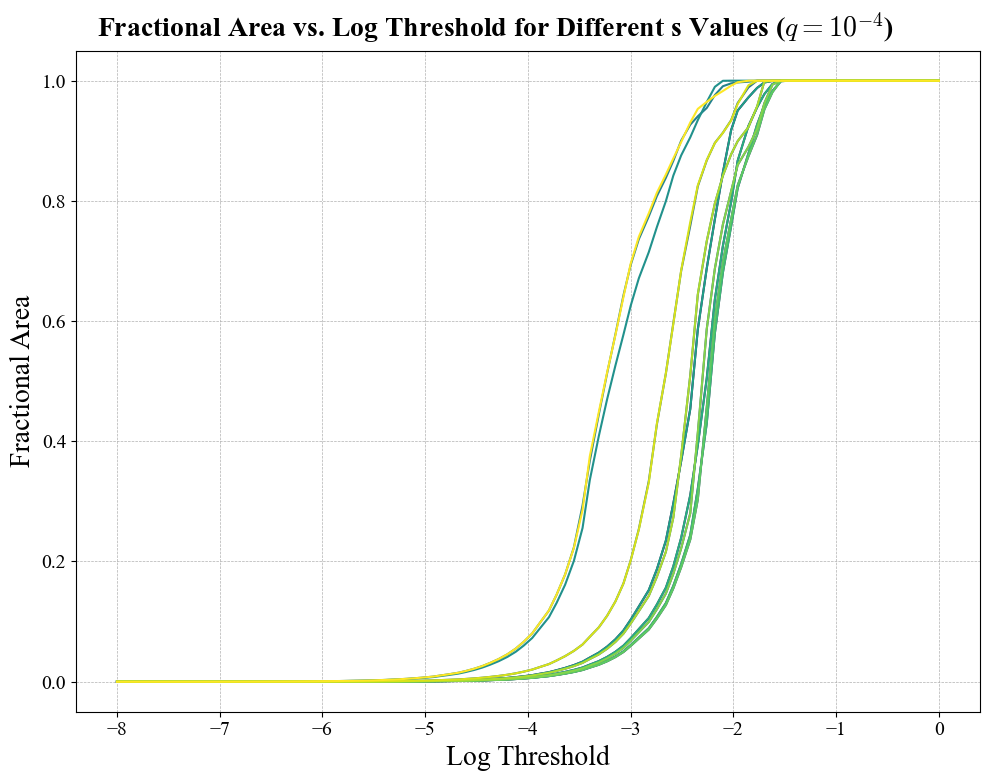

In [21]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Fractional Area vs. Log Threshold for Different s Values ($q=10^{-4}$)', y=0.97)

df_subset = df_2[df_2['q'] == 1e-4]

colors = plt.cm.viridis(np.linspace(0, 1, len(ss_str_unique_2)))
ax.set_prop_cycle(color=colors)
lines = []

for i, s in enumerate(ss_str_unique_2):
    df_s = df_subset[df_subset['s'] == s]
    fractional_areas = df_s.iloc[:, 4:].mean(axis=0).to_list()
    line = ax.plot(np.log10(thresholds_2), fractional_areas, label=f's = {s}')
    lines.append(line[0])

# bar = fig.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=ax, pad=0.01)
# bar.set_label('s values', rotation=270, labelpad=15)

ax.set_xlabel('Log Threshold')
ax.set_ylabel('Fractional Area')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

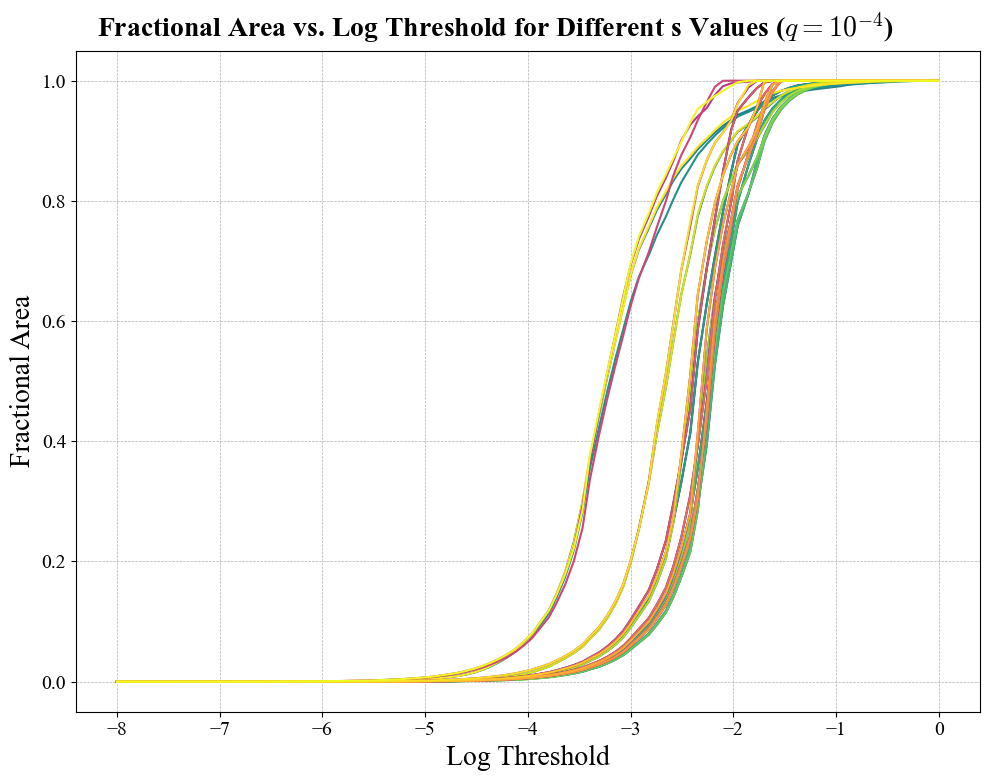

In [20]:
fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Fractional Area vs. Log Threshold for Different s Values ($q=10^{-4}$)', y=0.97)

df_subset_1 = df_1[df_1['q'] == 1e-4]
df_subset_2 = df_2[df_2['q'] == 1e-4]

colors_1 = plt.cm.viridis(np.linspace(0, 1, len(ss_str_unique_1)))
ax.set_prop_cycle(color=colors_1)
lines_1 = []

for i, s in enumerate(ss_str_unique_1):
    df_s = df_subset_1[df_subset_1['s'] == s]
    fractional_areas = df_s.iloc[:, 4:].mean(axis=0).to_list()
    line = ax.plot(np.log10(thresholds_1), fractional_areas, label=f's = {s}')
    lines_1.append(line[0])

colors_2 = plt.cm.plasma(np.linspace(0, 1, len(ss_str_unique_2)))
ax.set_prop_cycle(color=colors_2)
lines_2 = []

for i, s in enumerate(ss_str_unique_2):
    df_s = df_subset_2[df_subset_2['s'] == s]
    fractional_areas = df_s.iloc[:, 4:].mean(axis=0).to_list()
    line = ax.plot(np.log10(thresholds_2), fractional_areas, label=f's = {s}')
    lines_2.append(line[0])

# bar = fig.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=ax, pad=0.01)
# bar.set_label('s values', rotation=270, labelpad=15)

ax.set_xlabel('Log Threshold')
ax.set_ylabel('Fractional Area')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()